In [30]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import cv2

In [31]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

In [32]:
def scale(image,label):
  image = tf.cast(image, tf.float32)
  image /= 255.
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [33]:
BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [34]:
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)
validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape,validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [35]:
input_size = 784
output_size = 10

hidden_layer_size = 50

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
NUM_EPOCHS = 30

early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose=1)

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8811 - loss: 0.4112 - val_accuracy: 0.9417 - val_loss: 0.2077
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9506 - loss: 0.1715 - val_accuracy: 0.9535 - val_loss: 0.1549
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9611 - loss: 0.1320 - val_accuracy: 0.9580 - val_loss: 0.1382
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9677 - loss: 0.1085 - val_accuracy: 0.9617 - val_loss: 0.1241
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9725 - loss: 0.0933 - val_accuracy: 0.9632 - val_loss: 0.1247
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9768 - loss: 0.0792 - val_accuracy: 0.9642 - val_loss: 0.1170
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9798 - loss: 0.0686 - val_accuracy: 0.9652 - val_loss: 0.1123
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9819 - loss: 0.0604 - val_accuracy:

In [37]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 924ms/step - accuracy: 0.9728 - loss: 0.1100
Test loss: 0.11. Test accuracy: 97.28%


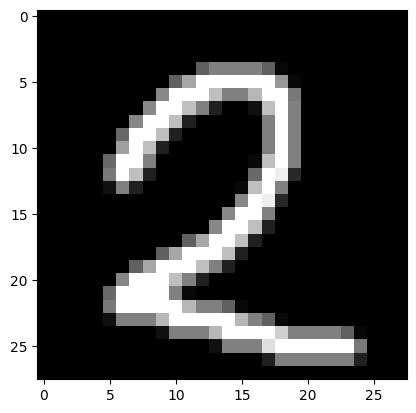

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted class: 2


In [49]:
my_image = cv2.imread("my_image.png")
my_image = cv2.cvtColor(my_image, cv2.COLOR_BGR2GRAY)
#my_image = cv2.resize(my_image, (28, 28))
my_image = my_image.reshape(1, 28, 28, 1)
my_image = my_image / 255.0
plt.imshow(my_image.reshape(28, 28), cmap='gray')
plt.show()
predictions = model.predict(my_image)
predicted_class = np.argmax(predictions)
print("Predicted class:", predicted_class)
